In [7]:
import numpy as np
import tensortools as tt
import matplotlib.pyplot as plt

## Tensor Decompositions for neural data analysis

In this tutorial, you will learn how to fit and analyze tensor decompositions as applied to neural data. The tutorial is broken into three parts:

__Part 1__: Applying tensor decompositions to synthetic data

__Part 2__: Walking through fitting a tensor decomposition

__Part 3__: Applying TCA to neural data

The three parts are independent, and if you are already familiar with TCA feel free to skip to __Part 3__.



# Part 1: Applying tensor decompositions to synthetic data

# Part 2: Fitting a tensor decomposition

# Part 3: Applying TCA to neural data


In [3]:
# Download the DANDI dataset

! dandi download DANDI:000127/0.220113.0359

P+q544e\P+q524742\P+q636f6c6f7273\P+q626c696e6b\P+q7369746d\P+q7269746d\P+q6376766973\P+q536d756c78\P+q536574756c63\P+q4d73\PATH                 SIZE DONE    DONE% CHECKSUM STATUS MESSAGE   
000127/dandiset.yaml                                    updating  
Summary:                  0 Bytes                       1 updating
                          <0.00%                                  
000127/dandiset.yaml                             done   updated   
Summary:                  0 Bytes                1 done 1 updated 
                          <0.00%                                  PATH                            SIZE    DONE    DONE% CHECKSUM STATUS MESSAGE   
000127/dandiset.yaml                                           done   updated   
...ub-Han_desc-test_ecephys.nwb                                                 
Summary:                        0 Bytes 0 Bytes                1 done 1 updated 
                                +1.8 GB 0.00%                   

In [8]:
from nlb_tools.nwb_interface import NWBDataset
filepath = "/Users/colin/Documents/Python/tca_tutorial/000127/sub-Han/sub-Han_desc-train_behavior+ecephys.nwb"
dataset = NWBDataset(filepath, split_heldout=False)

In [9]:
dataset.data

/Users/colin/Documents/Python/tca_tutorial/.venv/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


signal_type                force                                          \
channel                        x       xmo         y       ymo         z   
clock_time                                                                 
0 days 00:00:00         0.111601 -0.016411 -0.016132  0.031638 -0.860530   
0 days 00:00:00.001000  0.112149 -0.016385 -0.016735  0.031656 -0.863162   
0 days 00:00:00.002000  0.112128 -0.016337 -0.017959  0.031570 -0.867022   
0 days 00:00:00.003000  0.112120 -0.016303 -0.019839  0.031548 -0.875458   
0 days 00:00:00.004000  0.112348 -0.016271 -0.021298  0.031409 -0.878765   
...                          ...       ...       ...       ...       ...   
0 days 00:37:03.444000  0.109535  0.015883 -0.358220 -0.038800  0.325109   
0 days 00:37:03.445000  0.103208  0.014566 -0.344428 -0.039158  0.283674   
0 days 00:37:03.446000  0.112367  0.014230 -0.341114 -0.037992  0.238139   
0 days 00:37:03.447000  0.134583  0.014858 -0.348047 -0.035429  0.189791   
0 days 00:37:03.448000  0.159886  0.015918 -0.357272 -0.032395  0.142843   

signal_type                       hand_pos             hand_vel            \
channel                      zmo         x         y          x         y   
clock_time                                                                  
0 days 00:00:00        -0.019057 -0.718481 -0.646707   0.121506 -0.913109   
0 days 00:00:00.001000 -0.019053 -0.718354 -0.647619   0.134653 -0.910121   
0 days 00:00:00.002000 -0.019009 -0.718212 -0.648527   0.150593 -0.904744   
0 days 00:00:00.003000 -0.018959 -0.718053 -0.649428   0.169150 -0.897144   
0 days 00:00:00.004000 -0.018881 -0.717874 -0.650321   0.190097 -0.887522   
...                          ...       ...       ...        ...       ...   
0 days 00:37:03.444000  0.012868  5.166923  3.234832 -24.981190 -6.696567   
0 days 00:37:03.445000  0.012906  5.141971  3.228088 -24.920175 -6.787637   
0 days 00:37:03.446000  0.013054  5.117082  3.221257 -24.854795 -6.872403   
0 days 00:37:03.447000  0.013406  5.092261  3.214344 -24.784820 -6.949949   
0 days 00:37:03.448000  0.013792  5.067513  3.207357 -24.710058 -7.019430   

signal_type             ... spikes                                          \
channel                 ...   7801 8401 8501 8801 8901 9001 9101 9401 9501   
clock_time              ...                                                  
0 days 00:00:00         ...    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:00:00.001000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:00:00.002000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:00:00.003000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:00:00.004000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
...                     ...    ...  ...  ...  ...  ...  ...  ...  ...  ...   
0 days 00:37:03.444000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:37:03.445000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:37:03.446000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:37:03.447000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
0 days 00:37:03.448000  ...    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

signal_type                  
channel                9601  
clock_time                   
0 days 00:00:00         0.0  
0 days 00:00:00.001000  0.0  
0 days 00:00:00.002000  0.0  
0 days 00:00:00.003000  0.0  
0 days 00:00:00.004000  0.0  
...                     ...  
0 days 00:37:03.444000  0.0  
0 days 00:37:03.445000  0.0  
0 days 00:37:03.446000  0.0  
0 days 00:37:03.447000  0.0  
0 days 00:37:03.448000  0.0  

[2223449 rows x 167 columns]

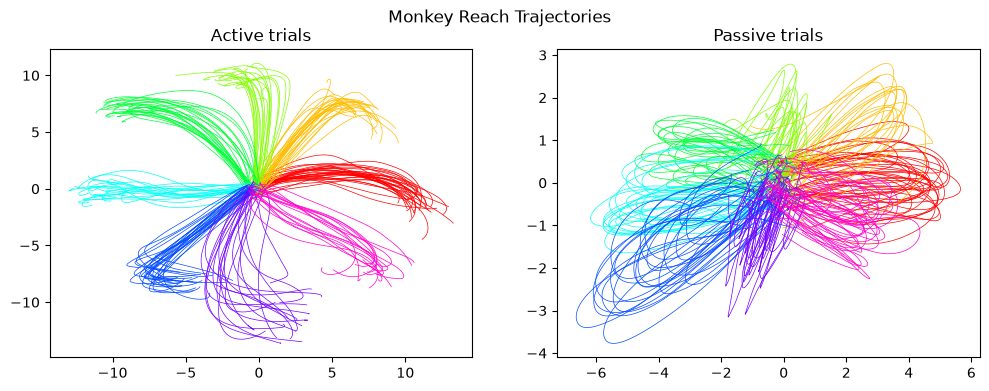

In [10]:
# All 16 conditions, in the format (ctr_hold_bump, cond_dir)
unique_conditions = [(False, 0.0), (False, 45.0), (False, 90.0), (False, 135.0),
                     (False, 180.0), (False, 225.0), (False, 270.0), (False, 315.0),
                     (True, 0.0), (True, 45.0), (True, 90.0), (True, 135.0),
                     (True, 180.0), (True, 225.0), (True, 270.0), (True, 315.0)]

# Initialize figure
fig = plt.figure(figsize=(12, 4))
ax_act = fig.add_subplot(1, 2, 1)
ax_pas = fig.add_subplot(1, 2, 2)

# Loop through conditions
for cond in unique_conditions:
    # Filter out invalid trials (labeled 'none') and trials in other conditions
    cond_mask = (np.all(dataset.trial_info[['ctr_hold_bump', 'cond_dir']] == cond, axis=1)) & \
                (dataset.trial_info.split != 'none')
    # Extract relevant portion of selected trials
    cond_data = dataset.make_trial_data(align_field='move_onset_time', align_range=(-100, 500), ignored_trials=~cond_mask)
    # Plot reaches on appropriate subplot
    for idx, trial in cond_data.groupby('trial_id'):
        if cond[0]: # Passive trials
            ax_pas.plot(trial.hand_pos.x, trial.hand_pos.y, color=plt.cm.hsv(cond[1] / 360), linewidth=0.5)
        else: # Active trials
            ax_act.plot(trial.hand_pos.x, trial.hand_pos.y, color=plt.cm.hsv(cond[1] / 360), linewidth=0.5)

# Add labels
ax_act.set_title('Active trials')
ax_pas.set_title('Passive trials')
fig.suptitle(f'Monkey Reach Trajectories')
plt.show()

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

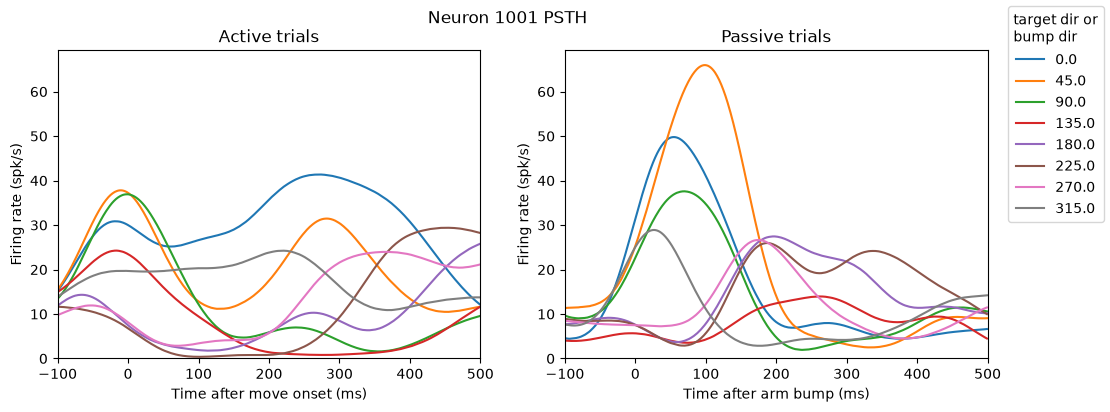

In [11]:
## Plot PSTH

# Smooth spikes with 40 ms std Gaussian kernel
dataset.smooth_spk(40, name='smth_40')

# plot PSTHs for neuron 1001
neur_num = 1001

# All 16 conditions, in the format (ctr_hold_bump, cond_dir)
unique_conditions = [(False, 0.0), (False, 45.0), (False, 90.0), (False, 135.0),
                     (False, 180.0), (False, 225.0), (False, 270.0), (False, 315.0),
                     (True, 0.0), (True, 45.0), (True, 90.0), (True, 135.0),
                     (True, 180.0), (True, 225.0), (True, 270.0), (True, 315.0)]

# Initialize figure
fig = plt.figure(figsize=(12, 4))
ax_act = fig.add_subplot(1, 2, 1)
ax_pas = fig.add_subplot(1, 2, 2, sharex=ax_act, sharey=ax_act)

# Loop through conditions
for cond in unique_conditions:
    # Filter out invalid trials (labeled 'none') and trials in other conditions
    cond_mask = (np.all(dataset.trial_info[['ctr_hold_bump', 'cond_dir']] == cond, axis=1)) & \
                (dataset.trial_info.split != 'none')
    # Extract relevant portion of selected trials
    cond_data = dataset.make_trial_data(align_field='move_onset_time', align_range=(-100, 500), ignored_trials=~cond_mask)
    # Align and average data across trials
    cond_psth = cond_data.groupby('align_time')[[('spikes_smth_40', neur_num)]].mean().to_numpy() / dataset.bin_width * 1000
    # Plot on appropriate subplot
    if cond[0]: # Passive trials
        ax_pas.plot(np.arange(-100, 500, dataset.bin_width), cond_psth, label=cond[1])
    else: # Active trials
        ax_act.plot(np.arange(-100, 500, dataset.bin_width), cond_psth)

# Add labels
ax_act.set_xlim(-100, 500)
ax_act.set_ylim(0)
ax_act.set_xlabel('Time after move onset (ms)')
ax_pas.set_xlabel('Time after arm bump (ms)')
ax_act.set_ylabel('Firing rate (spk/s)')
ax_pas.set_ylabel('Firing rate (spk/s)')
ax_act.set_title('Active trials')
ax_pas.set_title('Passive trials')
fig.legend(title='target dir or\nbump dir')
fig.suptitle(f'Neuron {neur_num} PSTH')
plt.show()

In [ ]:
#Build data tensor from all trials

data = dataset.make_trial_data(align_field = 'move_onset_time', align_range=(-100,500))

# construct a trial x neuron # x time (ms) tensor of reaching movements across directions and passive / active trials
data_tensor = np.stack(data.groupby('align_time')['spikes_smth_40'].apply(np.array).to_list()).transpose((1,2,0))
print(data_tensor.shape)


(475, 65, 600)
